1. Heisenberg's principle

This is talking about orbitl component $L$ not $J = L + S$. However, we can ignore spin $S=0$ and then we're able to use our equations from class. We'll use $\hbar = 1$, but to keep track of adding them back in, each application of an operator $L_i$ contributes one $\hbar$

$$
\def\braket#1{\langle #1 \rangle}
\def\ket#1{|#1\rangle}
\def\bra#1{\langle #1 |}

    \braket{L_i} = \braket{l,m| L_i |l,m}
\\  \Delta L_i = \sqrt{\braket{L_i^2}-\braket{L_i}^2}
\\  L_z \ket{l,m} = m \ket{l,m}
\\  \braket{L_z}  = m
$$

By default we usually use $\ket{l,m}$ an eigenstate of $L_z$, but not the other two states. It's apparent from the ladder operator definitions of $L_x$ and $L_y$ that their expectation values are zero
$$
\def\Bra#1{\left\langle #1 \right|}
\def\Ket#1{\left| #1 \right\rangle}
\def\ac#1#2{\left\{ #1, #2 \right\}}
    \braket{L_x} = \bra{l,m}\left(L_+ + L_- \over 2 \right) \ket{l,m}
\\  \braket{L_y} = \bra{l,m}\left(L_+ - L_- \over 2i\right) \ket{l,m}
$$
Since the ladder operators send $\ket{l,m}$ to $\ket{l,m\pm 1}$, there is no overlap between bra and ket, yielding $\braket{L_x}=\braket{L_y}=0$. The squared operators are different,

$$
      L_x L_x
    = \left(L_+ + L_- \over 2 \right)\left(L_+ + L_- \over 2 \right)
    = {1 \over 4} \left(L_+^2 + L_-^2 + \ac{L_+}{L_-}  \right)
\\    L_y L_y
    = \left(L_+ - L_- \over 2i\right)\left(L_+ - L_- \over 2i\right)
    = -{1 \over 4} \left(L_+^2 + L_-^2 - \ac{L_+}{L_-}  \right)
$$
where only the anticommutator survives measurement.

$$
      \bra{l,m} L_+ L_-  \ket{l,m}
    = \sqrt{(l+m)(l-m+1)}
      \bra{l,m} L_+ \ket{l, m-1}
\\  = \sqrt{(l+m)(l-m+1)}
      \sqrt{(l-(m-1))(l+(m-1)+1)}
      \braket{l,m|l,m}
\\  = (l+m)(l-m+1)
\\    \bra{l,m} L_- L_+  \ket{l,m}
    = \sqrt{(l-m)(l+m+1)}
      \bra{l,m} L_+ \ket{l, m+1}
\\  = (l-m)(l+m+1)
\\[0.5em]    
      \bra{l,m} \ac{L_+}{L_+}\ket{l,m}
    = (l+m)(l-m+1)
    + (l-m)(l+m+1)
    = 2l^2 + 2l - 2m^2
\\[1em]
    \braket{L_x^2} = \braket{L_y^2} = {1 \over 4} \left(2l^2 + 2l - 2m^2\right)
    = {l^2 + l + m^2 \over 2}
$$
For those keeping track, that's two $\hbar$'s.
Alongside the zero expectation value of $L_x$ and $L_y$, this yields

$$
\Delta L_x = \Delta L_y = \sqrt{l^2 + l + m^2 \over 2},
$$
and for $L_z$ we have
$$
    \braket{L_z^2} = m^2
\\  \Delta L_z = \sqrt{m^2-m^2} = 0.
$$
So, for the $z$-eigenstate $\ket{l,m}$, we have

$$
\Delta L_x \Delta L_y = {l^2 + l + m^2 \over 2},
$$
with the other uncertainty pairs evaluating out to zero


2. Gravitino representation. A spin $3/2$ particle can have four momenta

$$
j = 3/2, \quad m = 3/2, 1/2, -1/2, -3/2
$$
Is the representation just the matricies for $J_i$? Let's use python to do the tedious calculations

In [57]:
import numpy as np
from sympy import sqrt

j = 3/2
m_vals = np.arange(j, -j-1, -1)
bra, ket = np.meshgrid(m_vals, m_vals, indexing='ij')

j2 = j*(j+1)*np.eye(len(m_vals))

jz = np.where(bra == ket, ket, 0)

jp_mask = (bra == ket + 1)
jp_coeffs = np.sqrt(j*(j+1) - ket*(ket + 1))
jp = np.where(jp_mask, jp_coeffs, 0)

jm_mask = (bra == ket - 1)
jm_coeffs = np.sqrt(j*(j+1) - ket*(ket - 1))
jm = np.where(jm_mask, jm_coeffs, 0)

with np.printoptions(precision=2):
    print('J^2: \n', j2, '\n Jz: \n', jz, '\n J+: \n', jp, '\n J-:\n', jm)
    print('Jx: \n', (jp+jm)/2, '\n Jy: \n', -1j/2*(jp-jm))


J^2: 
 [[3.75 0.   0.   0.  ]
 [0.   3.75 0.   0.  ]
 [0.   0.   3.75 0.  ]
 [0.   0.   0.   3.75]] 
 Jz: 
 [[ 1.5  0.   0.   0. ]
 [ 0.   0.5  0.   0. ]
 [ 0.   0.  -0.5  0. ]
 [ 0.   0.   0.  -1.5]] 
 J+: 
 [[0.   1.73 0.   0.  ]
 [0.   0.   2.   0.  ]
 [0.   0.   0.   1.73]
 [0.   0.   0.   0.  ]] 
 J-:
 [[0.   0.   0.   0.  ]
 [1.73 0.   0.   0.  ]
 [0.   2.   0.   0.  ]
 [0.   0.   1.73 0.  ]]
Jx: 
 [[0.   0.87 0.   0.  ]
 [0.87 0.   1.   0.  ]
 [0.   1.   0.   0.87]
 [0.   0.   0.87 0.  ]] 
 Jy: 
 [[0.-0.j   0.-0.87j 0.-0.j   0.-0.j  ]
 [0.+0.87j 0.-0.j   0.-1.j   0.-0.j  ]
 [0.-0.j   0.+1.j   0.-0.j   0.-0.87j]
 [0.-0.j   0.-0.j   0.+0.87j 0.-0.j  ]]


Unfortunately numpy doesn't keep matricies nice and clean, but I don't really care.
$$
\sqrt{3} = 1.73 \dots
\\  \sqrt{3}/2 = 0.87 \dots
$$

3. Commutator.

Note that $J^2 = \vec J \cdot \vec J$, so we can use that to work around not knowing anything about $\vec L \cdot \vec S$. $\vec L$ and $\vec S$ commute since they operate on differet states.
$$
\def\J{\vec J}\def\S{\vec S}\def\L{\vec L}
      \J \cdot \J 
    = \left(\L+\S\right)\cdot\left(\L+\S\right)
    = \L^2 + \S^2 + 2 \L \cdot  \S
\\    2 \L \cdot \S 
    = J^2 - L^2 - S^2
$$
Each operator commutes with itself, so it should be very easy from here
$$
\def\c#1#2{\left[#1,#2\right]}
\begin{align*}
      \c{\J}{\L \cdot \S}
   &= {1 \over 2} \left(\c{\J}{J^2}-\c{\J}{L^2}-  \c{\J}{S^2} \right)
\\ &= {1 \over 2} \left(0-\c{\L + \S}{L^2}-  \c{\L + \S}{S^2} \right)
\end{align*}
$$
by linearity, these expand to self-commutators and commutators between $\L$ ad $\S$, so it must equal zero.
$$
\c{\J}{\L\cdot \S} = 0
$$

4. $x$-basis for $\sigma$. We'll use the eigenvector method, but I bet it'll look a lot like $\sigma_z$

$$
P^{-1} \sigma_x P = D
$$

Eigendecomposition is unitary since $\sigma_x$ is real. The eigenvalues/vectors of $\sigma_x$ are $-1 \begin{pmatrix} 1 \\ -1 \end{pmatrix}$
and $1 \begin{pmatrix} 1 \\ 1 \end{pmatrix}$

$$
\begin{pmatrix}
    {1\over 2} & {1 \over 2} \\ {1 \over 2} & -{1 \over 2} 
\end{pmatrix}
\begin{pmatrix} 0 & 1 \\ 1 &  0 \end{pmatrix}
\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}
= 
\begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}
$$
This transforms $\sigma_y$ and $\sigma_z$ into
$$
    P^{-1} \sigma_y P = -\sigma_y
\\  P^{-1} \sigma_z P =  \sigma_z
$$


In [ ]:
from sympy import *
sx = Matrix([[0,1],[1,0]])
sy = Matrix([[0,-1*I],[1*I, 0]])
sz = Matrix([[1, 0  ],[0  ,-1]])
P = Matrix([[1,1],[1,-1]])
Pinv = Inverse(P).doit()
display(Pinv)
display(Pinv * sy * P)
display(Pinv * sz * P)

Matrix([
[1/2,  1/2],
[1/2, -1/2]])

Matrix([
[ 0, I],
[-I, 0]])

Matrix([
[0, 1],
[1, 0]])

5. Page 223 of Sakurai or Desai 11.2.2? Rederiving Wigner's formula would mostly be following the textbook, which is already step-by-step, so I'll just put down my solution to Desai here.


$$  
\def\c#1#2{\left[#1,#2\right]}

      \c{A_{\pm}}{A_z} 
    = \c{a_{\pm}^\dag a_{\mp}}{a_+^\dag a_+ - a_-^\dag a_-}
\\  = \c{a_{\pm}^\dag a_{\mp}}{a_+^\dag a_+} 
    - \c{a_{\pm}^\dag a_{\mp}}{a_-^\dag a_-}
$$
using $\c{a_i}{a_j^\dag}=\delta_{ij}$ and the previous problem, this reduces to

$$
\\    \c{A_+}{A_z}
    = a^\dag_+ \c{a_+^\dag}{a_+} a_-
    - a_+^\dag \c{a_-}{a_-^\dag} a_-
    = \dots
\\  = - 2A_+
\\    \c{A_-}{A_z}
    = a_-^\dag \c{a_+}{a_+^\dag} a_+
    - a_-^\dag \c{a_-^\dag}{a_-} a_+
    = \dots
\\  = 2A_-
$$
I got the result mutiplied by $-2$?

$$
      A_x^2 + A_y^2 
    = {1 \over 2} \left(A_+ A_- + A_- A_+ \right)
% \\  = {1 \over 2} \left( a_+^\dag a_+ + a_-^\dag a_-)
\\    \c{A^2}{A_z} 
    = \c{A_z^2 + {1 \over 2} A_+ A_- + {1 \over 2} A_- A_+ }{A_z}
\\  = {1 \over 2} \c{A_+A_-}{A_z}
    + {1 \over 2} \c{A_-A_+}{A_z}
$$
Apply $\c{AB}{C} = A\c{B}{C} + \c{A}{C}B$
$$
    = {1 \over 2} \left(
        A_+\c{A_-}{A_z} + \c{A_+}{A_z}A_-
    +   A_-\c{A_+}{A_z} + \c{A_-}{A_z}A_+
        \right)
\\  = 
        A_+A_- - A_+A_-
    -   A_-A_+ + A_-A_+
    = 0
$$
Not too sure what I did wrong here, but using the commutator relation provided, this would be
$$
      {1 \over 2} \left(
        A_+\c{A_-}{A_z} + \c{A_+}{A_z}A_-
    +   A_-\c{A_+}{A_z} + \c{A_-}{A_z}A_+
        \right)
\\  = {1 \over 2}\left(
      -A_+ A_- + A_+ A_- 
    + A_- A_+ - A_-A_+
      \right)
$$
which isn't any better. Oh well, out of time.

6. Rotation and $J$. Again, using $\hbar =1$

$$
J_x = {1 \over \sqrt{2}} \begin{pmatrix}
    0 & 1 & 0
\\  1 & 0 & 1
\\  0 & 1 & 0
\end{pmatrix}
\quad
J_y = {1 \over \sqrt{2}i} \begin{pmatrix}
    0 & 1 & 0
\\ -1 & 0 & 1
\\  0 &-1 & 0
\end{pmatrix}
\quad
J_z = \begin{pmatrix}
    1 & 0 & 0
\\  0 & 0 & 0
\\  0 & 0 &-1
\end{pmatrix}
$$
What did we have in math class again?
$$
J_x'= \begin{pmatrix}
    0 & 0 & 0
\\  0 & 0 & 1
\\  0 &-1 & 0
\end{pmatrix}
\quad
J_y'= \begin{pmatrix}
    0 & 0 &-1
\\  0 & 0 & 0
\\  1 & 0 & 0
\end{pmatrix}
\quad
J_z'= \begin{pmatrix}
    0 & 1 & 0
\\ -1 & 0 & 0
\\  0 & 0 & 0
\end{pmatrix}
$$

Before continuing, note that $J_z$ cannot be written as a sum of $J_i'$, which I believe is where the hint is coming from.

$$
    -\lambda^3-\lambda = 0
\\  \lambda \ket{\lambda} = 
                    { i }\begin{pmatrix} {-i \over \sqrt{2}} \\ {1 \over \sqrt{2}} \\ 0 \end{pmatrix},
                    {-i }\begin{pmatrix} { i \over \sqrt{2}} \\ {1 \over \sqrt{2}} \\ 0 \end{pmatrix},
                                      0\begin{pmatrix}  0 \\ 0 \\ 1 \end{pmatrix}
$$
I want the result to look like $J_z$, so during diagonalization I'll Use something like $P = \left[ \ket{i} \ket{0} \ket{-i}\right]$. 

I actually attempted this problem twice, with the first attempt yielding the correct transformation of $J_z$, but not $J_x$ or $J_y$. This is because of my choice of $\ket{\lambda}$. Since quantum mechanics allows for an arbitrary phase factor $e^{i\theta}$, my choice of eigenvectors caused the off-diagonal values to be off. I just guessed a different phase (mutliplied by $-i = e^{i3\pi/2}$), but one could hone into the correct phase if they left it in the equations $\ket{\lambda} \rightarrow e^{i\theta_\lambda} \ket{\lambda}$ and multiplied through to the end result of transforming.


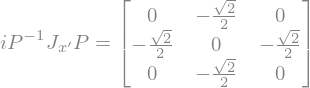

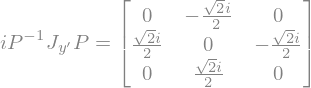

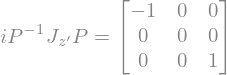

In [47]:
from sympy import *
P = Matrix([[-1/sqrt(2),I/sqrt(2),0],
            [0,         0,        1],
            [ 1/sqrt(2),I/sqrt(2),0]]).T
Pinv = P.H
Psymb = MatrixSymbol('P', 3, 3)
Jxyz_symb = [MatrixSymbol(x, 3, 3) for x in ['J_x\'', 'J_y\'', 'J_z\'']]

Jxp = Matrix([[0, 0, 0],[ 0, 0, 1],[0,-1, 0]])
Jyp = Matrix([[0, 0,-1],[ 0, 0, 0],[1, 0, 0]])
Jzp = Matrix([[0, 1, 0],[-1, 0, 0],[0, 0, 0]])

display(Eq(I*Psymb.inverse()*Jxyz_symb[0]*Psymb, -I*(Pinv * Jxp * P)))
display(Eq(I*Psymb.inverse()*Jxyz_symb[1]*Psymb, -I*(Pinv * Jyp * P)))
display(Eq(I*Psymb.inverse()*Jxyz_symb[2]*Psymb, -I*(Pinv * Jzp * P)))

Note that there's an additional $i$ thrown in there, this is because of the difference in definitions of generators in math / physics, I think?